# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


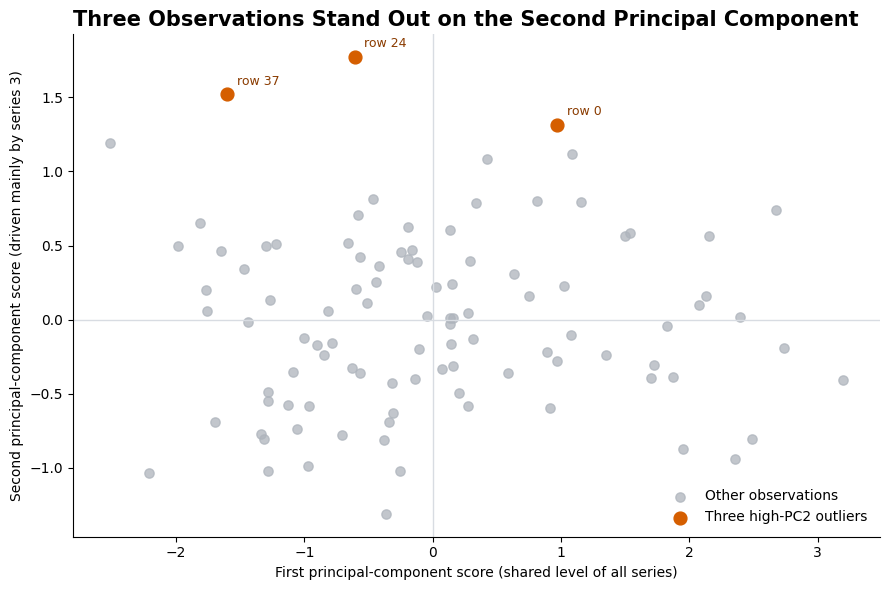

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
fig, ax = plt.subplots(figsize=(9, 6))
outlier_indices = second_principal_component_score.nlargest(3).index
regular = ~df.index.isin(outlier_indices)
ax.scatter(first_principal_component_score[regular], second_principal_component_score[regular],
           color="#AEB4BC", alpha=.75, s=45, label="Other observations")
ax.scatter(first_principal_component_score.loc[outlier_indices],
           second_principal_component_score.loc[outlier_indices],
           color="#D55E00", s=85, label="Three high-PC2 outliers", zorder=3)
for index in outlier_indices:
    ax.annotate(f"row {index}",
                (first_principal_component_score.loc[index],
                 second_principal_component_score.loc[index]),
                xytext=(7, 7), textcoords="offset points", fontsize=9, color="#8A3B00")
ax.axhline(0, color="#D8DCE2", linewidth=1)
ax.axvline(0, color="#D8DCE2", linewidth=1)
ax.set_title("Three Observations Stand Out on the Second Principal Component",
             loc="left", fontsize=15, weight="bold")
ax.set_xlabel("First principal-component score (shared level of all series)")
ax.set_ylabel("Second principal-component score (driven mainly by series 3)")
ax.legend(frameon=False, loc="lower right")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### Weekly graph response

The three upper-left points have **low first-component scores** and **high second-component scores**. From the fitted loadings printed above, PC2 is driven mainly by `ser3`, so these points have unusually high `ser3` relative to their overall level. PC1 moves all three series together; a low PC1 score therefore indicates a lower combined level (the signs of all PCA vectors may flip without changing the interpretation).

It is much harder to infer separate values for `ser1` and `ser2` because they were deliberately created to be almost the same: `ser2 = ser1 x (1 + small noise)`. PCA places their common movement mainly in PC1. Their small difference is largely relegated to PC3, which is absent from this graph. Consequently, a point's location in the PC1-PC2 plane cannot reveal which of `ser1` or `ser2` is larger.

The plot's advantage is dimensional reduction: two axes retain nearly all variance and reveal three observations with unusual `ser3` behavior. Its disadvantages are interpretability and information loss. Component axes are weighted combinations rather than original units, signs are arbitrary, and omitting PC3 hides the small but real distinction between `ser1` and `ser2`. A loading table and labels for the outliers would make the plot more actionable.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

## Completed analysis: mortgage loan-default dataset

I use `DATA/Loan_Default.csv`, the same established course dataset analyzed in prior weeks. The business question is whether loan structure and borrower affordability reveal meaningful risk segments. `Status = 1` denotes default. To make PCA loadings comparable, the selected numeric features are median-imputed and standardized.

In [2]:
import seaborn as sns
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

loan_path = Path("DATA/Loan_Default.csv")
loans = pd.read_csv(loan_path)
features = ["loan_amount", "property_value", "income", "LTV", "Credit_Score", "dtir1"]
loan_model_data = loans[features + ["Status"]].replace([np.inf, -np.inf], np.nan)

print(f"Rows: {len(loans):,}; default rate: {loans['Status'].mean():.1%}")
display(loan_model_data[features].describe().T[["count", "mean", "std", "min", "50%", "max"]].round(2))

Rows: 148,670; default rate: 24.6%


,count,mean,std,min,50%,max
loan_amount,148670.0,331117.74,183909.31,16500.00,296500.00,3576500.00
property_value,133572.0,497893.47,359935.32,8000.00,418000.00,16508000.00
income,139520.0,6957.34,6496.59,0.00,5760.00,578580.00
LTV,133572.0,72.75,39.97,0.97,75.14,7831.25
Credit_Score,148670.0,699.79,115.88,500.00,699.00,900.00
dtir1,124549.0,37.73,10.55,5.00,39.00,61.00


### Quintile-count heatmaps: one for each selected dataset

The Week 8 milk-and-cheese heatmap is recreated below for both selected loan datasets. Each axis is divided into five equal-sized groups, and each cell counts observations rather than averaging an outcome. Ranking before `qcut` breaks repeated-value ties deterministically, which guarantees five equal-sized groups even when many loans share the same dollar amount.

In [3]:
loans.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='str')

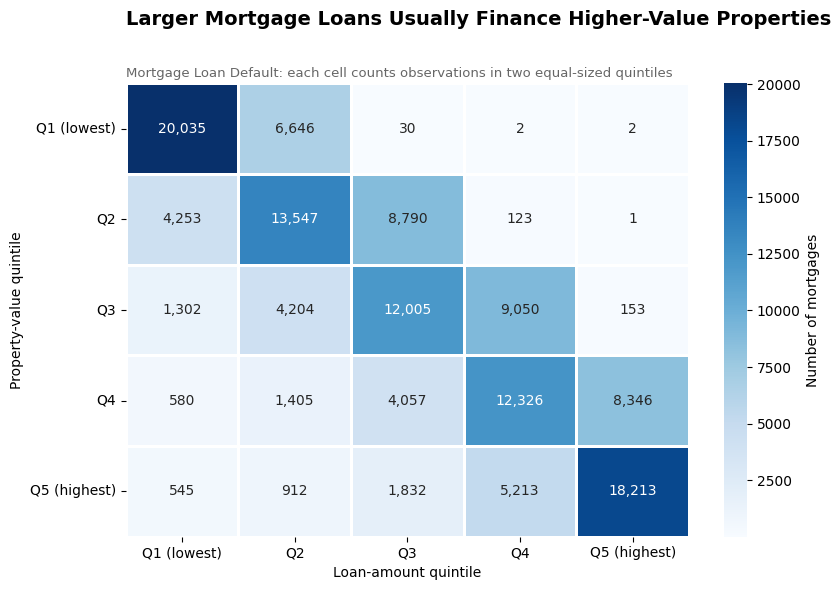

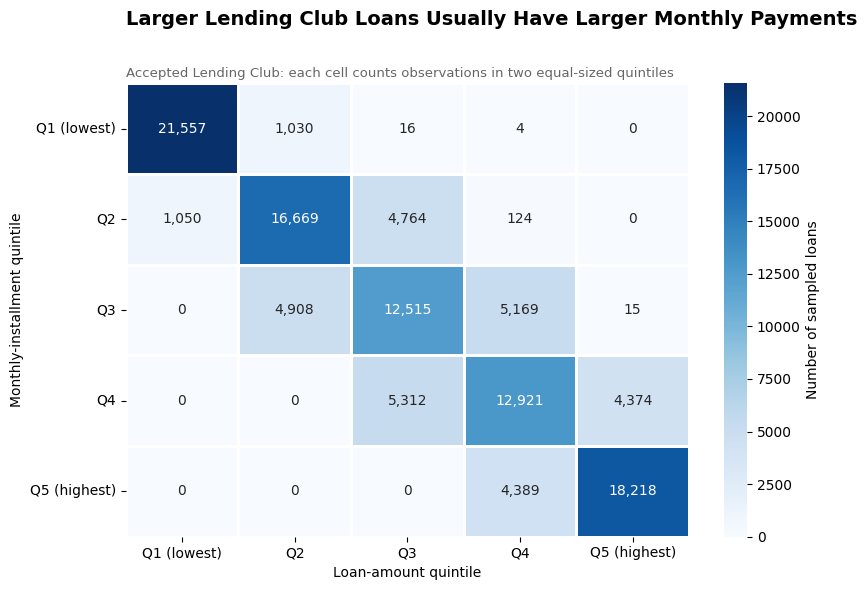

In [4]:
# Recreate the Week 8 quintile-count heatmap for each selected dataset.
quintile_labels = ["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"]

def quintile_count_grid(data, x_column, y_column):
    """Return a 5 x 5 count table with equal-sized, tie-safe quintiles."""
    plot_data = data[[x_column, y_column]].dropna().copy()
    plot_data[f"{x_column}_quintile"] = pd.qcut(
        plot_data[x_column].rank(method="first"),
        5,
        labels=quintile_labels
    )
    plot_data[f"{y_column}_quintile"] = pd.qcut(
        plot_data[y_column].rank(method="first"),
        5,
        labels=quintile_labels
    )
    return pd.crosstab(
        plot_data[f"{y_column}_quintile"],
        plot_data[f"{x_column}_quintile"]
    )

# Dataset 1: Mortgage Loan Default.
mortgage_heatmap_source = loans[["loan_amount", "property_value"]]
mortgage_counts = quintile_count_grid(
    mortgage_heatmap_source, "loan_amount", "property_value"
)

# Dataset 2: Accepted Lending Club.
# A fixed 5% sample from every file chunk keeps the notebook memory-efficient while
# representing the full 2007-2018 file instead of only its earliest rows.
accepted_path = Path(
    "DATA/All Lending Club Loan Data/accepted_2007_to_2018Q4.csv.gz"
)
accepted_chunks = []
for chunk_number, chunk in enumerate(pd.read_csv(
    accepted_path,
    usecols=["loan_amnt", "installment"],
    chunksize=200_000,
    low_memory=False
)):
    accepted_chunks.append(
        chunk.dropna().sample(frac=0.05, random_state=42 + chunk_number)
    )
accepted_heatmap_source = pd.concat(accepted_chunks, ignore_index=True)
accepted_counts = quintile_count_grid(
    accepted_heatmap_source, "loan_amnt", "installment"
)

heatmap_specs = [
    (
        mortgage_counts,
        "Mortgage Loan Default",
        "Loan-amount quintile",
        "Property-value quintile",
        "Larger Mortgage Loans Usually Finance Higher-Value Properties",
        "Number of mortgages"
    ),
    (
        accepted_counts,
        "Accepted Lending Club",
        "Loan-amount quintile",
        "Monthly-installment quintile",
        "Larger Lending Club Loans Usually Have Larger Monthly Payments",
        "Number of sampled loans"
    ),
]

for counts, dataset_name, x_label, y_label, title, colorbar_label in heatmap_specs:
    fig, ax = plt.subplots(figsize=(8.5, 6))
    sns.heatmap(
        counts,
        annot=True,
        fmt=",d",
        cmap="Blues",
        linewidths=1,
        linecolor="white",
        cbar_kws={"label": colorbar_label},
        ax=ax
    )
    ax.set_title(title, loc="left", fontsize=14, weight="bold", pad=42)
    ax.text(
        0,
        1.015,
        f"{dataset_name}: each cell counts observations in two equal-sized quintiles",
        transform=ax.transAxes,
        fontsize=9.5,
        color="#666666"
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

**Interpretation.** Both heatmaps concentrate observations near the diagonal. In the mortgage data, larger loan amounts generally accompany higher property values. In the accepted Lending Club data, larger loan amounts generally produce larger monthly installments. Cells away from the diagonal reflect other financing terms and borrower circumstances; the heatmaps show association, not causation.

### Mortgage heatmap: default rate by affordability segment

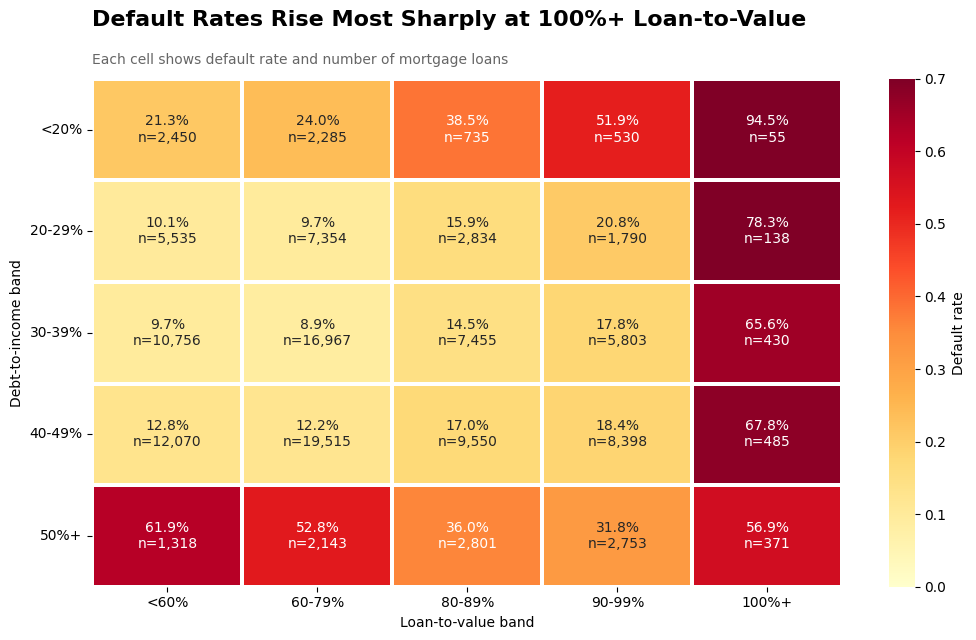

In [5]:
# Show both the default rate and the number of loans behind each cell.
heatmap_data = loans.loc[
    loans["LTV"].between(0, 150) & loans["dtir1"].between(0, 65),
    ["LTV", "dtir1", "Status"]
].copy()
heatmap_data["LTV band"] = pd.cut(
    heatmap_data["LTV"], [0, 60, 80, 90, 100, 151], right=False,
    labels=["<60%", "60-79%", "80-89%", "90-99%", "100%+"]
)
heatmap_data["DTI band"] = pd.cut(
    heatmap_data["dtir1"], [0, 20, 30, 40, 50, 66], right=False,
    labels=["<20%", "20-29%", "30-39%", "40-49%", "50%+"]
)
default_grid = heatmap_data.pivot_table(
    index="DTI band", columns="LTV band", values="Status", aggfunc="mean", observed=True
)
count_grid = heatmap_data.pivot_table(
    index="DTI band", columns="LTV band", values="Status", aggfunc="size", observed=True
)
annotations = default_grid.copy().astype(object)
for row in default_grid.index:
    for column in default_grid.columns:
        rate = default_grid.loc[row, column]
        count = int(count_grid.loc[row, column])
        annotations.loc[row, column] = f"{rate:.1%}\nn={count:,}"

fig, ax = plt.subplots(figsize=(10.5, 6.5))
sns.heatmap(
    default_grid, annot=annotations, fmt="", cmap="YlOrRd", vmin=0, vmax=.70,
    linewidths=1.5, linecolor="white", cbar_kws={"label": "Default rate"}, ax=ax
)
ax.set_title("Default Rates Rise Most Sharply at 100%+ Loan-to-Value",
             loc="left", fontsize=16, weight="bold", pad=38)
ax.text(0, 1.03, "Each cell shows default rate and number of mortgage loans",
        transform=ax.transAxes, fontsize=10, color="#666666")
ax.set_xlabel("Loan-to-value band")
ax.set_ylabel("Debt-to-income band")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

The heatmap shows that default risk is not evenly distributed. Risk generally rises in the upper LTV and DTI bands, supporting the affordability hypothesis. Sparse or extreme segments should be interpreted cautiously because a rate based on few loans is less stable.

### Mortgage bubble plot: loan size, property value, and affordability

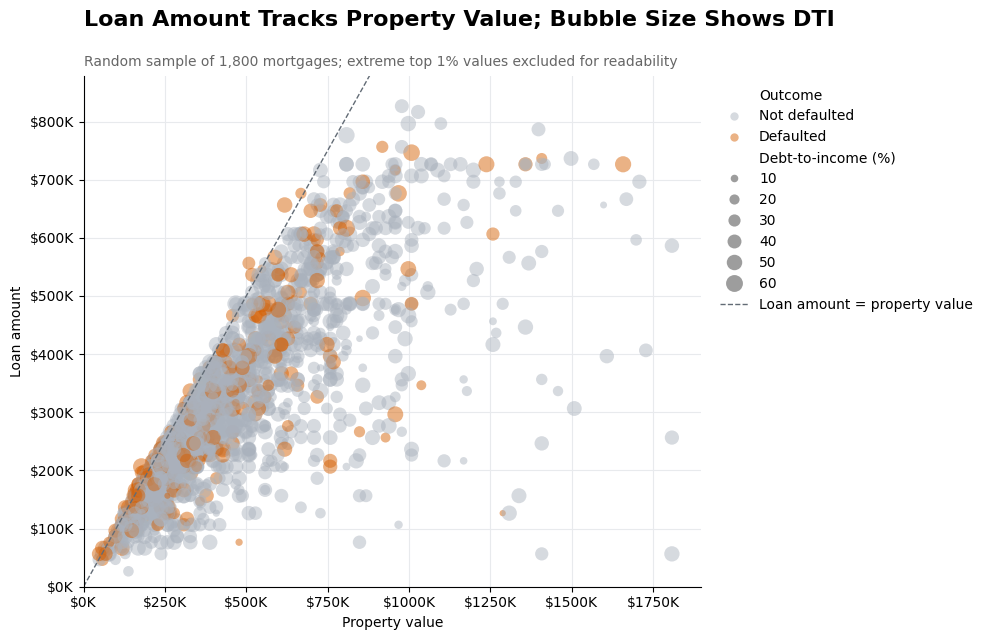

In [6]:
# A bounded sample keeps genuine structure visible instead of letting a few extreme
# property values compress the majority of observations.
bubble_source = loans.loc[
    loans["loan_amount"].notna()
    & loans["property_value"].notna()
    & loans["dtir1"].between(5, 65),
    ["loan_amount", "property_value", "dtir1", "Status"]
].copy()
property_cap = bubble_source["property_value"].quantile(.99)
loan_cap = bubble_source["loan_amount"].quantile(.99)
bubble_sample = (
    bubble_source.loc[
        bubble_source["property_value"].le(property_cap)
        & bubble_source["loan_amount"].le(loan_cap)
    ]
    .sample(1800, random_state=42)
)

fig, ax = plt.subplots(figsize=(10, 6.5))
sns.scatterplot(
    data=bubble_sample, x="property_value", y="loan_amount", size="dtir1",
    hue="Status", palette={0: "#AAB2BD", 1: "#D55E00"},
    sizes=(18, 150), alpha=.48, linewidth=0, ax=ax
)
ax.plot([0, property_cap], [0, property_cap], color="#626B75", linestyle="--",
        linewidth=1, label="Loan amount = property value")
ax.set_xlim(0, property_cap * 1.03)
ax.set_ylim(0, loan_cap * 1.05)
ax.set_title("Loan Amount Tracks Property Value; Bubble Size Shows DTI",
             loc="left", fontsize=16, weight="bold", pad=36)
ax.text(0, 1.02, "Random sample of 1,800 mortgages; extreme top 1% values excluded for readability",
        transform=ax.transAxes, fontsize=10, color="#666666")
ax.set_xlabel("Property value")
ax.set_ylabel("Loan amount")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"${value/1_000:.0f}K"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"${value/1_000:.0f}K"))
handles, labels = ax.get_legend_handles_labels()
friendly = {"0": "Not defaulted", "1": "Defaulted", "Status": "Outcome",
            "dtir1": "Debt-to-income (%)"}
labels = [friendly.get(label, label) for label in labels]
ax.legend(handles, labels, bbox_to_anchor=(1.01, 1), loc="upper left",
          frameon=False, title=None)
ax.grid(color="#E8EAED")
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Loan amount and property value form a strong rising relationship, so they contain partially redundant information. Larger DTI bubbles occur across the plot, and defaults are mixed with non-defaults rather than cleanly separated. This confirms that no single two-dimensional view perfectly distinguishes risk.

### Mortgage principal component analysis

,loan_amount,property_value,income,LTV,Credit_Score,dtir1
PC1,0.589,0.599,0.504,-0.129,0.005,-0.155
PC2,0.339,0.119,-0.173,0.495,-0.012,0.772
PC3,0.031,-0.224,0.304,0.770,-0.310,-0.409
PC4,0.014,-0.077,0.094,0.257,0.950,-0.124
PC5,-0.229,-0.352,0.777,-0.168,0.001,0.437
PC6,0.697,-0.668,-0.102,-0.227,-0.004,-0.080


,explained_variance,cumulative_variance
PC1,34.4%,34.4%
PC2,18.4%,52.8%
PC3,16.9%,69.7%
PC4,16.6%,86.3%
PC5,9.3%,95.6%
PC6,4.4%,100.0%


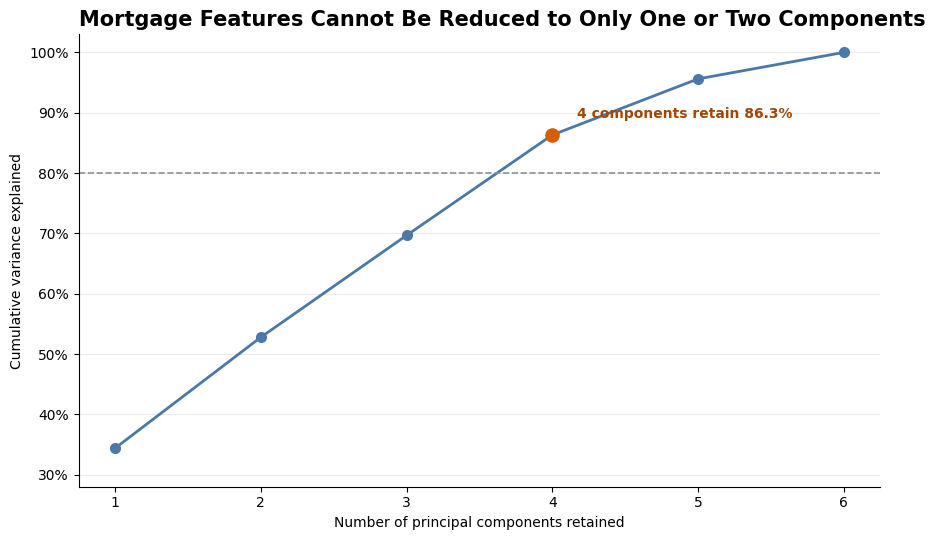

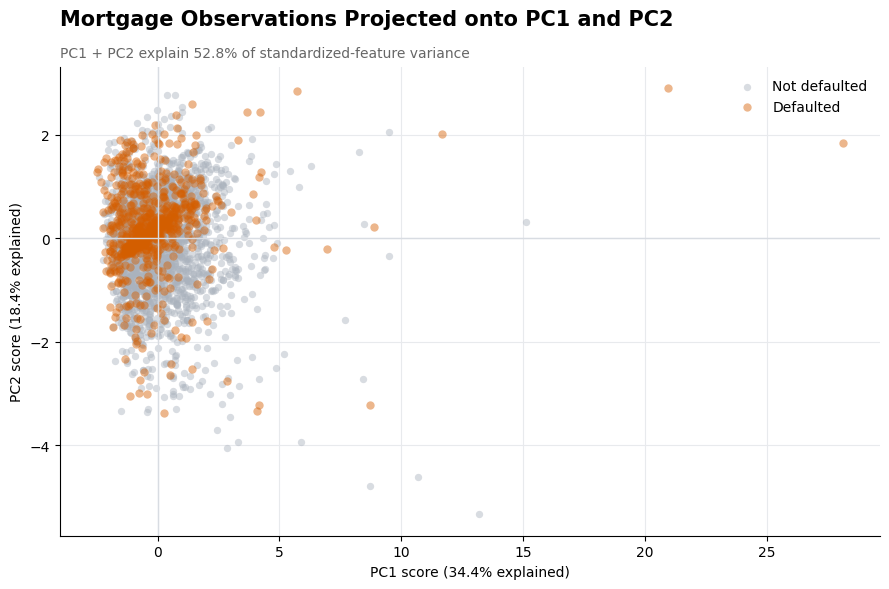

In [7]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_imputed = imputer.fit_transform(loan_model_data[features])
X_scaled = scaler.fit_transform(X_imputed)

loan_pca = decomposition.PCA(n_components=len(features)).fit(X_scaled)
loan_loadings = pd.DataFrame(
    loan_pca.components_, columns=features,
    index=[f"PC{i}" for i in range(1, len(features)+1)]
)
loan_variance = pd.DataFrame({
    "explained_variance": loan_pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(loan_pca.explained_variance_ratio_)
}, index=loan_loadings.index)
display(loan_loadings.round(3))
display(loan_variance.style.format("{:.1%}"))

scores = loan_pca.transform(X_scaled)
cumulative = np.cumsum(loan_pca.explained_variance_ratio_)
components_for_80 = int(np.argmax(cumulative >= .80) + 1)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(range(1, len(features)+1), cumulative, marker="o", markersize=7,
        color="#4C78A8", linewidth=2)
ax.axhline(.80, color="#8B929A", linestyle="--", linewidth=1.2)
ax.scatter([components_for_80], [cumulative[components_for_80-1]],
           color="#D55E00", s=90, zorder=3)
ax.annotate(
    f"{components_for_80} components retain {cumulative[components_for_80-1]:.1%}",
    (components_for_80, cumulative[components_for_80-1]),
    xytext=(18, 12), textcoords="offset points", color="#A34700", weight="bold"
)
ax.set_xticks(range(1, len(features)+1))
ax.set_ylim(.28, 1.03)
ax.set_xlabel("Number of principal components retained")
ax.set_ylabel("Cumulative variance explained")
ax.set_title("Mortgage Features Cannot Be Reduced to Only One or Two Components",
             loc="left", fontsize=15, weight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.grid(axis="y", color="#E8EAED")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

# Plot the first two PCA scores so dimension reduction can be assessed visually.
mortgage_score_frame = pd.DataFrame({
    "PC1": scores[:, 0],
    "PC2": scores[:, 1],
    "Status": loan_model_data["Status"].to_numpy()
}).sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
for status, label, color, size in [
    (0, "Not defaulted", "#AAB2BD", 28),
    (1, "Defaulted", "#D55E00", 36)
]:
    subset = mortgage_score_frame.loc[mortgage_score_frame["Status"].eq(status)]
    ax.scatter(
        subset["PC1"], subset["PC2"], label=label, color=color,
        s=size, alpha=.45, linewidth=0
    )
ax.axhline(0, color="#D8DCE2", linewidth=1)
ax.axvline(0, color="#D8DCE2", linewidth=1)
ax.set_title("Mortgage Observations Projected onto PC1 and PC2",
             loc="left", fontsize=15, weight="bold", pad=30)
ax.text(
    0, 1.02,
    f"PC1 + PC2 explain {cumulative[1]:.1%} of standardized-feature variance",
    transform=ax.transAxes, color="#666666", fontsize=10
)
ax.set_xlabel(f"PC1 score ({loan_pca.explained_variance_ratio_[0]:.1%} explained)")
ax.set_ylabel(f"PC2 score ({loan_pca.explained_variance_ratio_[1]:.1%} explained)")
ax.legend(frameon=False)
ax.grid(color="#E8EAED")
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

PC1 primarily captures the common scale of loan amount and property value. Other components contrast leverage, affordability, and borrower credit measures. The cumulative-variance curve shows whether one or two components are sufficient; here, meaningful variance remains beyond two components, so aggressive compression would discard useful structure. PCA signs are arbitrary, so interpretation depends on relative loading magnitudes and directions, not whether a vector is printed with plus or minus signs.

### Mortgage regression: which features predict default?

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    loan_model_data[features], loan_model_data["Status"], test_size=0.25,
    random_state=42, stratify=loan_model_data["Status"]
)

def evaluate_feature_set(selected_features):
    train_imputer = SimpleImputer(strategy="median")
    train_scaler = StandardScaler()
    Xtr = train_scaler.fit_transform(train_imputer.fit_transform(X_train[selected_features]))
    Xte = train_scaler.transform(train_imputer.transform(X_test[selected_features]))
    model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42).fit(Xtr, y_train)
    probability = model.predict_proba(Xte)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    return {"features": ", ".join(selected_features), "ROC_AUC": roc_auc_score(y_test, probability),
            "accuracy": accuracy_score(y_test, prediction)}

model_results = pd.DataFrame([
    evaluate_feature_set(["LTV", "dtir1"]),
    evaluate_feature_set(["loan_amount", "property_value", "income"]),
    evaluate_feature_set(features),
]).sort_values("ROC_AUC", ascending=False)
display(model_results.style.format({"ROC_AUC": "{:.3f}", "accuracy": "{:.3f}"}))

,features,ROC_AUC,accuracy
2,"loan_amount, property_value, income, LTV, Credit_Score, dtir1",0.586,0.552
1,"loan_amount, property_value, income",0.584,0.477
0,"LTV, dtir1",0.573,0.579


The full feature set performs best, but predictive power remains moderate rather than decisive. LTV and DTI provide interpretable affordability information; loan amount, property value, and income add scale; credit score adds borrower context. Logistic regression is used because default is binary. ROC AUC is emphasized because it evaluates ranking across thresholds and is more informative than raw accuracy for an imbalanced outcome.

### Mortgage conclusions and data-quality assessment

In [9]:
# Flag extreme observations using the standard 1.5 x IQR rule.
outlier_summary = []
for feature in features:
    series = loan_model_data[feature].dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    count = ((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum()
    outlier_summary.append({"feature": feature, "IQR_outliers": count, "share": count / len(series)})
display(pd.DataFrame(outlier_summary).sort_values("share", ascending=False)
        .style.format({"share": "{:.1%}"}))

,feature,IQR_outliers,share
2,income,6546,4.7%
1,property_value,5266,3.9%
5,dtir1,2013,1.6%
3,LTV,1882,1.4%
0,loan_amount,1895,1.3%
4,Credit_Score,0,0.0%


The data are usable for exploratory risk analysis, but not ready for production decisions without additional validation. Missing values require imputation, and LTV, income, loan amount, and property value contain extreme observations that should be reviewed rather than automatically deleted. Loan amount and property value are strongly related, creating redundancy. PCA supports retaining several dimensions rather than replacing the dataset with only one or two scores. The heatmap and regression agree that affordability matters, but overlapping classes show that default is multi-causal. Potential confounders include loan purpose, region, interest rate, employment stability, and underwriting policy. The next modeling step should combine these features with categorical variables and validate performance on a time-separated holdout set.

## Completed analysis: accepted Lending Club loans

This repeats the Week 9 multivariate workflow for the second selected dataset. The source is the accepted-loan CSV inside `DATA/All Lending Club Loan Data/accepted_2007_to_2018q4.csv`. An evenly spaced sample represents the full 2007–2018 source file without loading all multi-million rows into memory. A **bad-loan outcome** includes charged-off, defaulted, or late loans; this definition is kept separate from the mortgage dataset's `Status` field.

In [10]:
# Load an evenly spaced sample from the exact selected accepted-loan CSV.
from pathlib import Path

lending_path = Path("DATA/All Lending Club Loan Data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv")
lending_features = [
    "loan_amnt", "int_rate", "installment", "annual_inc", "dti",
    "fico_range_low", "open_acc", "revol_util", "total_acc"
]
lending_usecols = lending_features + ["grade", "purpose", "loan_status"]
lending_total_rows = sum(1 for _ in open(lending_path, encoding="utf-8")) - 1
lending_every = max(lending_total_rows // 60000, 1)
lending = pd.read_csv(
    lending_path,
    usecols=lending_usecols,
    skiprows=lambda row: row > 0 and row % lending_every != 0,
    low_memory=False
)
bad_statuses = {
    "Charged Off", "Default", "Late (31-120 days)", "Late (16-30 days)",
    "Does not meet the credit policy. Status:Charged Off"
}
lending["bad_loan"] = lending["loan_status"].isin(bad_statuses).astype(int)

print(f"Source file rows: {lending_total_rows:,}")
print(f"Evenly spaced analysis sample: {len(lending):,} rows")
print(f"Bad-loan rate in sample: {lending['bad_loan'].mean():.1%}")
display(
    lending[lending_features].describe().T[
        ["count", "mean", "std", "min", "50%", "max"]
    ].round(2)
)

Source file rows: 2,260,701
Evenly spaced analysis sample: 61,100 rows
Bad-loan rate in sample: 13.0%


,count,mean,std,min,50%,max
loan_amnt,61098.0,15054.89,9219.15,1000.00,13000.00,40000.00
int_rate,61098.0,13.09,4.82,5.31,12.62,30.99
installment,61098.0,446.35,268.35,30.12,378.04,1719.83
annual_inc,61098.0,78023.72,82063.51,0.00,65000.00,8365188.00
dti,61040.0,18.80,14.35,0.00,17.85,999.00
fico_range_low,61098.0,698.52,33.01,640.00,690.00,845.00
open_acc,61098.0,11.60,5.65,0.00,11.00,59.00
revol_util,61051.0,50.44,24.72,0.00,50.30,172.00
total_acc,61098.0,24.14,11.97,2.00,22.00,123.00


### Lending Club heatmap: bad-loan rate by grade and loan purpose

This heatmap repeats the mortgage matrix analysis using Lending Club's own categorical risk structure. Credit grade and the five most common loan purposes define the cells; each cell displays both the bad-loan rate and its loan count.

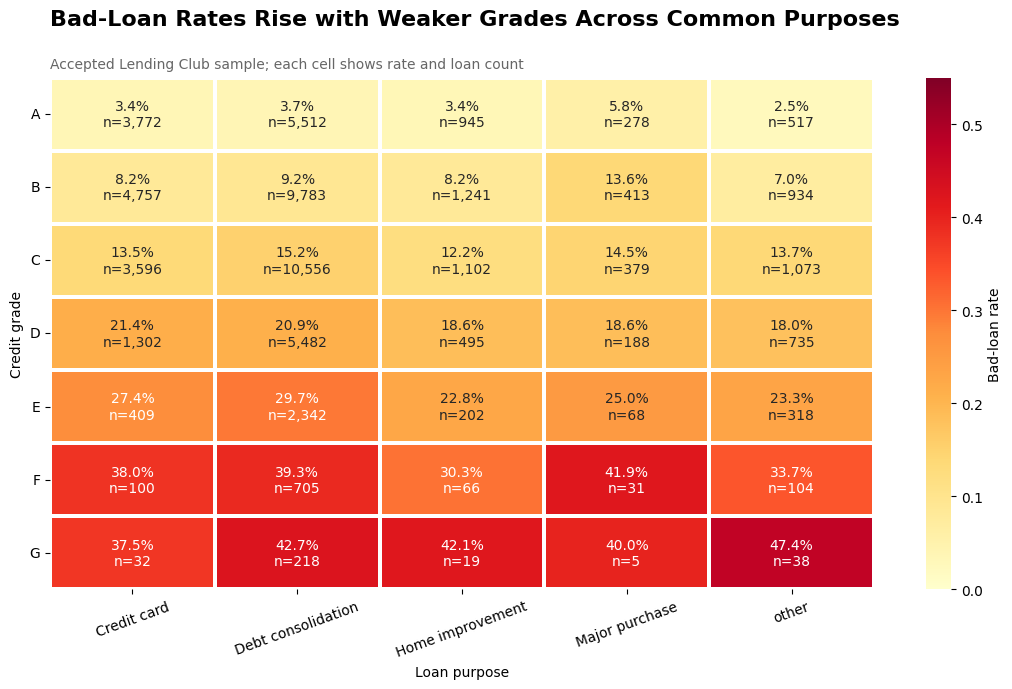

In [11]:
# Compare grade across the five most common purposes; this avoids the
# near-mechanical overlap between grade and interest-rate bands.
top_purposes = lending["purpose"].value_counts().head(5).index
lending_heatmap = lending.loc[
    lending["purpose"].isin(top_purposes)
].dropna(subset=["grade", "purpose", "bad_loan"]).copy()
lending_heatmap["Purpose"] = lending_heatmap["purpose"].replace({
    "debt_consolidation": "Debt consolidation",
    "credit_card": "Credit card",
    "home_improvement": "Home improvement",
    "major_purchase": "Major purchase",
    "small_business": "Small business"
})
lending_rate_grid = lending_heatmap.pivot_table(
    index="grade", columns="Purpose", values="bad_loan",
    aggfunc="mean", observed=True
)
lending_count_grid = lending_heatmap.pivot_table(
    index="grade", columns="Purpose", values="bad_loan",
    aggfunc="size", observed=True
)
lending_annotations = lending_rate_grid.copy().astype(object)
for row in lending_rate_grid.index:
    for column in lending_rate_grid.columns:
        rate = lending_rate_grid.loc[row, column]
        count = lending_count_grid.loc[row, column]
        lending_annotations.loc[row, column] = (
            "" if pd.isna(rate) else f"{rate:.1%}\nn={int(count):,}"
        )

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    lending_rate_grid, annot=lending_annotations, fmt="", cmap="YlOrRd",
    vmin=0, vmax=.55, linewidths=1.5, linecolor="white",
    cbar_kws={"label": "Bad-loan rate"}, ax=ax
)
ax.set_title("Bad-Loan Rates Rise with Weaker Grades Across Common Purposes",
             loc="left", fontsize=16, weight="bold", pad=38)
ax.text(0, 1.02, "Accepted Lending Club sample; each cell shows rate and loan count",
        transform=ax.transAxes, color="#666666", fontsize=10)
ax.set_xlabel("Loan purpose")
ax.set_ylabel("Credit grade")
ax.tick_params(axis="x", rotation=20)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

### Lending Club bubble plot: credit score, interest rate, and loan size

This plot shows individual accepted loans. Position carries FICO score and interest rate, bubble size carries loan amount, and color identifies the observed outcome.

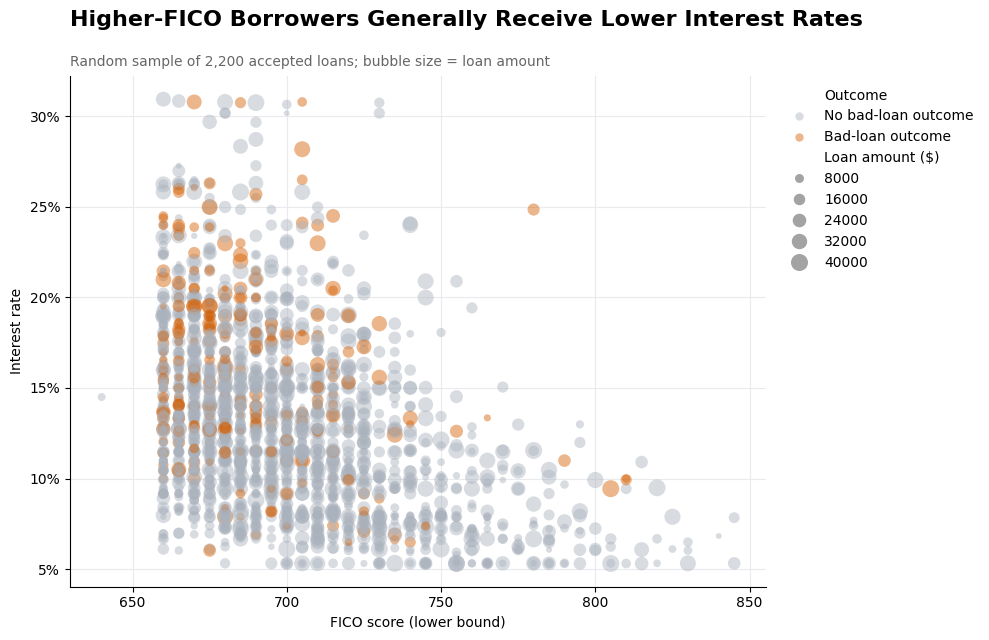

In [12]:
lending_bubble_source = lending.dropna(
    subset=["fico_range_low", "int_rate", "loan_amnt", "bad_loan"]
).copy()
lending_bubble = lending_bubble_source.sample(
    min(2200, len(lending_bubble_source)), random_state=42
)

fig, ax = plt.subplots(figsize=(10, 6.5))
sns.scatterplot(
    data=lending_bubble, x="fico_range_low", y="int_rate",
    size="loan_amnt", hue="bad_loan",
    palette={0: "#AAB2BD", 1: "#D55E00"},
    sizes=(18, 150), alpha=.45, linewidth=0, ax=ax
)
ax.set_title("Higher-FICO Borrowers Generally Receive Lower Interest Rates",
             loc="left", fontsize=16, weight="bold", pad=36)
ax.text(0, 1.02,
        f"Random sample of {len(lending_bubble):,} accepted loans; bubble size = loan amount",
        transform=ax.transAxes, color="#666666", fontsize=10)
ax.set_xlabel("FICO score (lower bound)")
ax.set_ylabel("Interest rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0f}%"))
handles, labels = ax.get_legend_handles_labels()
friendly = {
    "0": "No bad-loan outcome", "1": "Bad-loan outcome",
    "bad_loan": "Outcome", "loan_amnt": "Loan amount ($)"
}
labels = [friendly.get(label, label) for label in labels]
ax.legend(handles, labels, bbox_to_anchor=(1.01, 1), loc="upper left",
          frameon=False, title=None)
ax.grid(color="#E8EAED")
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### Lending Club principal component analysis

,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,open_acc,revol_util,total_acc
PC1,0.554,0.056,0.546,0.279,0.104,0.062,0.384,0.022,0.389
PC2,0.117,0.506,0.153,-0.051,0.113,-0.548,-0.199,0.560,-0.195
PC3,-0.336,0.149,-0.332,-0.192,0.367,-0.268,0.516,0.028,0.493
PC4,0.182,0.105,0.175,-0.595,0.630,0.315,-0.119,-0.160,-0.186
PC5,-0.093,-0.442,-0.103,0.489,0.591,0.107,-0.122,0.404,-0.086
PC6,-0.112,0.620,-0.116,0.537,0.234,0.127,-0.062,-0.453,-0.149
PC7,-0.083,0.356,-0.146,-0.043,-0.193,0.702,0.045,0.531,0.168
PC8,-0.016,-0.025,0.004,0.008,-0.051,0.046,0.715,0.094,-0.688
PC9,0.711,-0.002,-0.701,-0.003,0.003,-0.048,0.005,-0.009,-0.021


,explained_variance,cumulative_variance
PC1,26.2%,26.2%
PC2,20.5%,46.8%
PC3,17.0%,63.7%
PC4,11.4%,75.1%
PC5,9.0%,84.1%
PC6,7.6%,91.7%
PC7,4.6%,96.3%
PC8,3.1%,99.4%
PC9,0.6%,100.0%


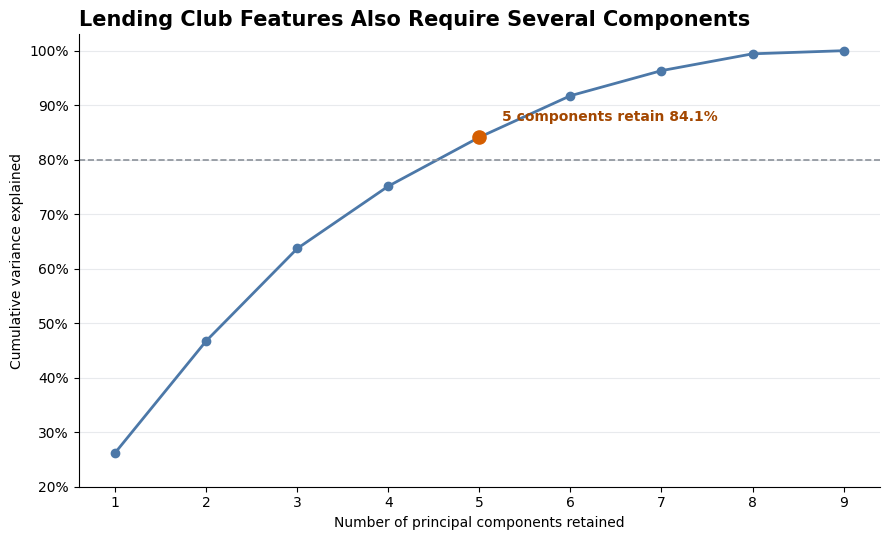

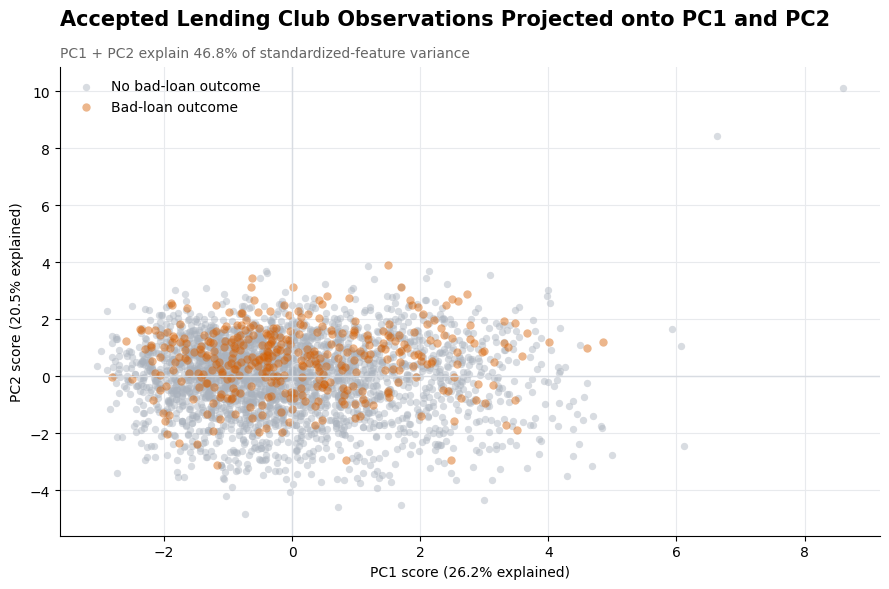

In [13]:
lending_imputer = SimpleImputer(strategy="median")
lending_scaler = StandardScaler()
lending_X_imputed = lending_imputer.fit_transform(lending[lending_features])
lending_X_scaled = lending_scaler.fit_transform(lending_X_imputed)
lending_pca = decomposition.PCA(n_components=len(lending_features)).fit(
    lending_X_scaled
)
lending_loadings = pd.DataFrame(
    lending_pca.components_,
    columns=lending_features,
    index=[f"PC{i}" for i in range(1, len(lending_features) + 1)]
)
lending_cumulative = np.cumsum(lending_pca.explained_variance_ratio_)
lending_components_for_80 = int(np.argmax(lending_cumulative >= .80) + 1)

display(lending_loadings.round(3))
display(pd.DataFrame({
    "explained_variance": lending_pca.explained_variance_ratio_,
    "cumulative_variance": lending_cumulative
}, index=lending_loadings.index).style.format("{:.1%}"))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(
    range(1, len(lending_features) + 1), lending_cumulative,
    color="#4C78A8", marker="o", linewidth=2
)
ax.axhline(.80, color="#8B929A", linestyle="--", linewidth=1.2)
ax.scatter(
    lending_components_for_80,
    lending_cumulative[lending_components_for_80 - 1],
    color="#D55E00", s=90, zorder=3
)
ax.annotate(
    f"{lending_components_for_80} components retain "
    f"{lending_cumulative[lending_components_for_80 - 1]:.1%}",
    (lending_components_for_80,
     lending_cumulative[lending_components_for_80 - 1]),
    xytext=(16, 12), textcoords="offset points",
    color="#A34700", weight="bold"
)
ax.set_xticks(range(1, len(lending_features) + 1))
ax.set_ylim(.20, 1.03)
ax.set_xlabel("Number of principal components retained")
ax.set_ylabel("Cumulative variance explained")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.set_title("Lending Club Features Also Require Several Components",
             loc="left", fontsize=15, weight="bold")
ax.grid(axis="y", color="#E8EAED")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

# Repeat the PC1-vs-PC2 score visualization for accepted Lending Club.
lending_scores = lending_pca.transform(lending_X_scaled)
lending_score_frame = pd.DataFrame({
    "PC1": lending_scores[:, 0],
    "PC2": lending_scores[:, 1],
    "bad_loan": lending["bad_loan"].to_numpy()
}).sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
for outcome, label, color, size in [
    (0, "No bad-loan outcome", "#AAB2BD", 28),
    (1, "Bad-loan outcome", "#D55E00", 36)
]:
    subset = lending_score_frame.loc[
        lending_score_frame["bad_loan"].eq(outcome)
    ]
    ax.scatter(
        subset["PC1"], subset["PC2"], label=label, color=color,
        s=size, alpha=.45, linewidth=0
    )
ax.axhline(0, color="#D8DCE2", linewidth=1)
ax.axvline(0, color="#D8DCE2", linewidth=1)
ax.set_title("Accepted Lending Club Observations Projected onto PC1 and PC2",
             loc="left", fontsize=15, weight="bold", pad=30)
ax.text(
    0, 1.02,
    f"PC1 + PC2 explain {lending_cumulative[1]:.1%} of standardized-feature variance",
    transform=ax.transAxes, color="#666666", fontsize=10
)
ax.set_xlabel(
    f"PC1 score ({lending_pca.explained_variance_ratio_[0]:.1%} explained)"
)
ax.set_ylabel(
    f"PC2 score ({lending_pca.explained_variance_ratio_[1]:.1%} explained)"
)
ax.legend(frameon=False)
ax.grid(color="#E8EAED")
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### Lending Club regression: which feature sets predict bad-loan outcomes?

In [14]:
from sklearn.pipeline import Pipeline

lending_X_train, lending_X_test, lending_y_train, lending_y_test = train_test_split(
    lending[lending_features], lending["bad_loan"], test_size=.25,
    random_state=42, stratify=lending["bad_loan"]
)

def evaluate_lending_features(selected_features):
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=42
        ))
    ])
    pipeline.fit(lending_X_train[selected_features], lending_y_train)
    probabilities = pipeline.predict_proba(
        lending_X_test[selected_features]
    )[:, 1]
    return {
        "feature_set": ", ".join(selected_features),
        "test_ROC_AUC": roc_auc_score(lending_y_test, probabilities)
    }

lending_regression_results = pd.DataFrame([
    evaluate_lending_features(["int_rate", "fico_range_low", "dti"]),
    evaluate_lending_features(["loan_amnt", "installment", "annual_inc"]),
    evaluate_lending_features(lending_features)
]).sort_values("test_ROC_AUC", ascending=False)
display(lending_regression_results.style.format({"test_ROC_AUC": "{:.3f}"}))

,feature_set,test_ROC_AUC
2,"loan_amnt, int_rate, installment, annual_inc, dti, fico_range_low, open_acc, revol_util, total_acc",0.680
0,"int_rate, fico_range_low, dti",0.679
1,"loan_amnt, installment, annual_inc",0.570


### Lending Club conclusions

The accepted-loan data are usable for exploratory risk analysis. Grade and interest rate produce clear adverse-outcome segmentation, while the bubble plot shows the expected inverse relationship between FICO score and interest rate. PCA indicates that one or two scores would discard substantial structure because the variables describe several distinct concepts: loan scale, pricing, borrower capacity, credit history, and account usage. The logistic comparisons test predictive usefulness on a held-out sample rather than on training data. Important limitations remain: the analysis covers accepted loans only, outcome statuses mature over different horizons, and the evenly spaced sample is not a substitute for time-based validation.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

## Plot 1 - Mortgage Loan Default

This figure applies Chapter 5's **visual hierarchy** lesson to the mortgage dataset. The LTV bands are the super-categories, while color and annotation direct attention to the tier with the highest observed default rate.

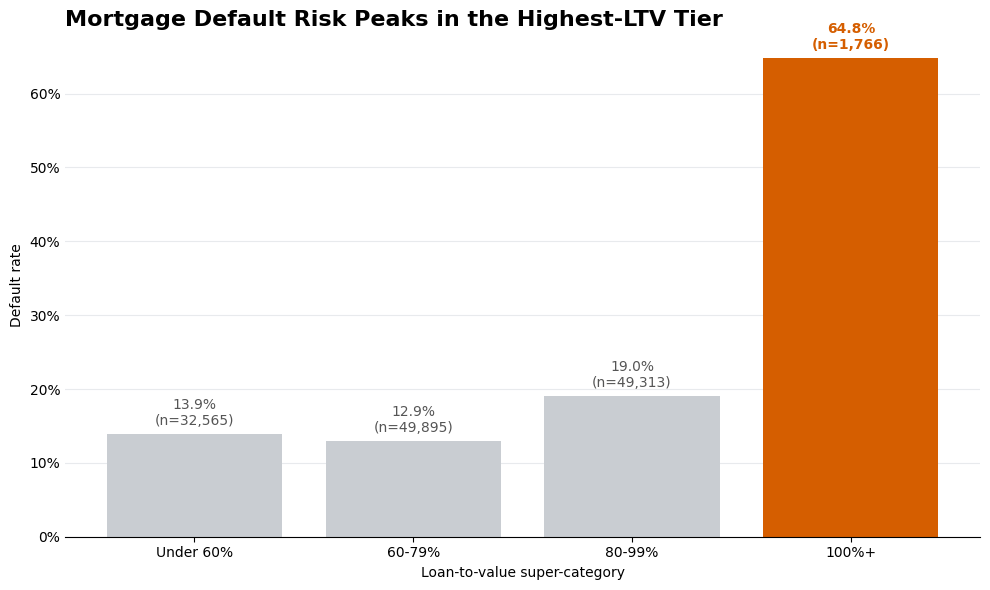

In [15]:
# Mortgage plot: visual hierarchy across LTV super-categories.
import matplotlib.ticker as mticker

mortgage_story = loans.loc[loans["LTV"].between(0, 150), ["LTV", "Status"]].copy()
mortgage_story["LTV tier"] = pd.cut(
    mortgage_story["LTV"], [0, 60, 80, 100, 151], right=False,
    labels=["Under 60%", "60-79%", "80-99%", "100%+"]
)
mortgage_rates = (
    mortgage_story.groupby("LTV tier", observed=True)["Status"]
    .agg(default_rate="mean", loans="size").reset_index()
)
highest_mortgage_index = mortgage_rates["default_rate"].idxmax()
colors = ["#D55E00" if index == highest_mortgage_index else "#C9CDD2"
          for index in mortgage_rates.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(mortgage_rates["LTV tier"].astype(str), mortgage_rates["default_rate"], color=colors)
for index, (bar, rate, count) in enumerate(zip(
    bars, mortgage_rates["default_rate"], mortgage_rates["loans"]
)):
    ax.text(bar.get_x() + bar.get_width()/2, rate + .012,
            f"{rate:.1%}\n(n={count:,})", ha="center",
            color="#D55E00" if index == highest_mortgage_index else "#555555",
            weight="bold" if index == highest_mortgage_index else "normal")

ax.set_title("Mortgage Default Risk Peaks in the Highest-LTV Tier",
             loc="left", fontsize=16, weight="bold")
ax.set_xlabel("Loan-to-value super-category")
ax.set_ylabel("Default rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis="y", color="#E8EAED")
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

**Mortgage takeaway.** LTV bands create an immediate hierarchy from lower to higher leverage. The highlighted bar is calculated from `DATA/Loan_Default.csv`; the design uses grey for context and orange only for the most important tier.

## Plot 2 - Accepted Lending Club Loans

This separate figure uses Lending Club credit grades as its super-categories. The ordered A-to-G scale supplies structure, and selective color emphasizes the weakest observed grades without mixing this dataset's outcome definition with mortgage defaults.

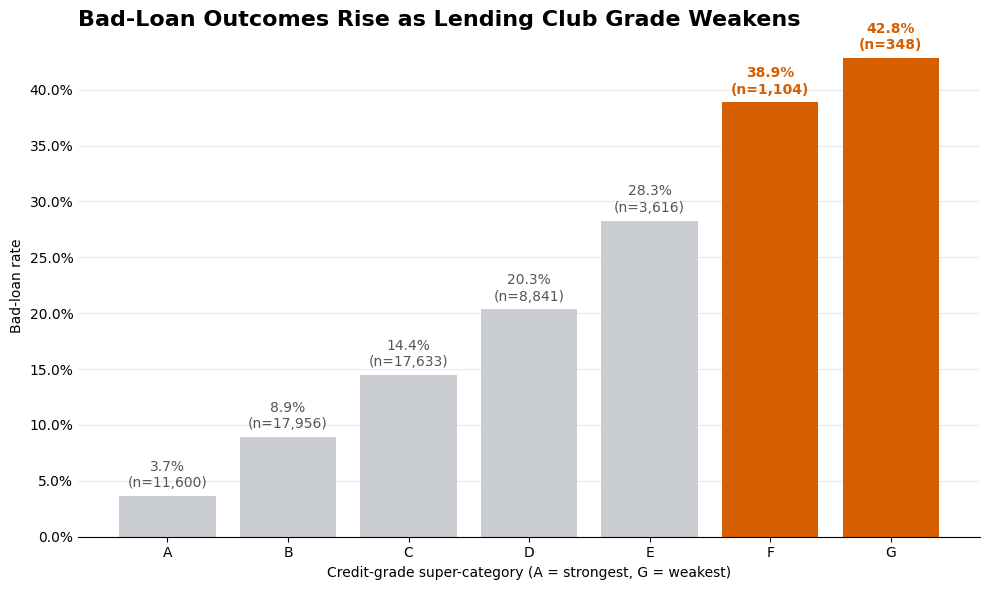

In [16]:
# Lending Club plot: hierarchy across ordered credit-grade super-categories.
from pathlib import Path

accepted_path = Path(
    "DATA/All Lending Club Loan Data/accepted_2007_to_2018q4.csv/"
    "accepted_2007_to_2018Q4.csv"
)
accepted_total_rows = sum(1 for _ in open(accepted_path, encoding="utf-8")) - 1
accepted_every = max(accepted_total_rows // 60000, 1)
accepted_story = pd.read_csv(
    accepted_path, usecols=["grade", "loan_status"],
    skiprows=lambda row: row > 0 and row % accepted_every != 0,
    low_memory=False
)
bad_statuses = {
    "Charged Off", "Default", "Late (31-120 days)", "Late (16-30 days)",
    "Does not meet the credit policy. Status:Charged Off"
}
accepted_story["bad_loan"] = accepted_story["loan_status"].isin(bad_statuses).astype(int)
lending_rates = (
    accepted_story.dropna(subset=["grade"]).groupby("grade")["bad_loan"]
    .agg(bad_loan_rate="mean", loans="size").reset_index().sort_values("grade")
)
colors = ["#D55E00" if grade in ["F", "G"] else "#C9CDD2"
          for grade in lending_rates["grade"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(lending_rates["grade"], lending_rates["bad_loan_rate"], color=colors)
for bar, grade, rate, count in zip(
    bars, lending_rates["grade"], lending_rates["bad_loan_rate"], lending_rates["loans"]
):
    ax.text(bar.get_x() + bar.get_width()/2, rate + .008,
            f"{rate:.1%}\n(n={count:,})", ha="center",
            color="#D55E00" if grade in ["F", "G"] else "#555555",
            weight="bold" if grade in ["F", "G"] else "normal")

ax.set_title("Bad-Loan Outcomes Rise as Lending Club Grade Weakens",
             loc="left", fontsize=16, weight="bold")
ax.set_xlabel("Credit-grade super-category (A = strongest, G = weakest)")
ax.set_ylabel("Bad-loan rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis="y", color="#E8EAED")
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

**Lending Club takeaway.** The ordered grades form a clear visual hierarchy, with F and G highlighted as the risk area. The result comes from an evenly spaced sample of the accepted-loan file. It is presented separately because `bad_loan` is not identical to the mortgage dataset's `Status` definition.